In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Read image in grayscale
image = cv2.imread("image.jpeg", cv2.IMREAD_GRAYSCALE)

In [3]:
# Get image size
height, width = image.shape

In [4]:
# =================================
# 1. Calculate Histogram Manually
# =================================

histogram = [0] * 256

for i in range(height):
    for j in range(width):
        pixel = image[i, j]
        histogram[pixel] += 1


In [5]:
# =================================
# 2. Calculate CDF
# =================================

cdf = [0] * 256

cdf[0] = histogram[0]

for i in range(1, 256):
    cdf[i] = cdf[i - 1] + histogram[i]

In [6]:
# =================================
# 3. Histogram Equalization
# =================================

total_pixels = height * width

equalized = np.zeros_like(image)

for i in range(height):
    for j in range(width):
        pixel = image[i, j]

        new_pixel = int((cdf[pixel] - cdf[0]) /
                        (total_pixels - cdf[0]) * 255)

        equalized[i, j] = new_pixel


In [7]:
# =================================
# 4. Calculate Equalized Histogram
# =================================

equalized_histogram = [0] * 256

for i in range(height):
    for j in range(width):
        pixel = equalized[i, j]
        equalized_histogram[pixel] += 1

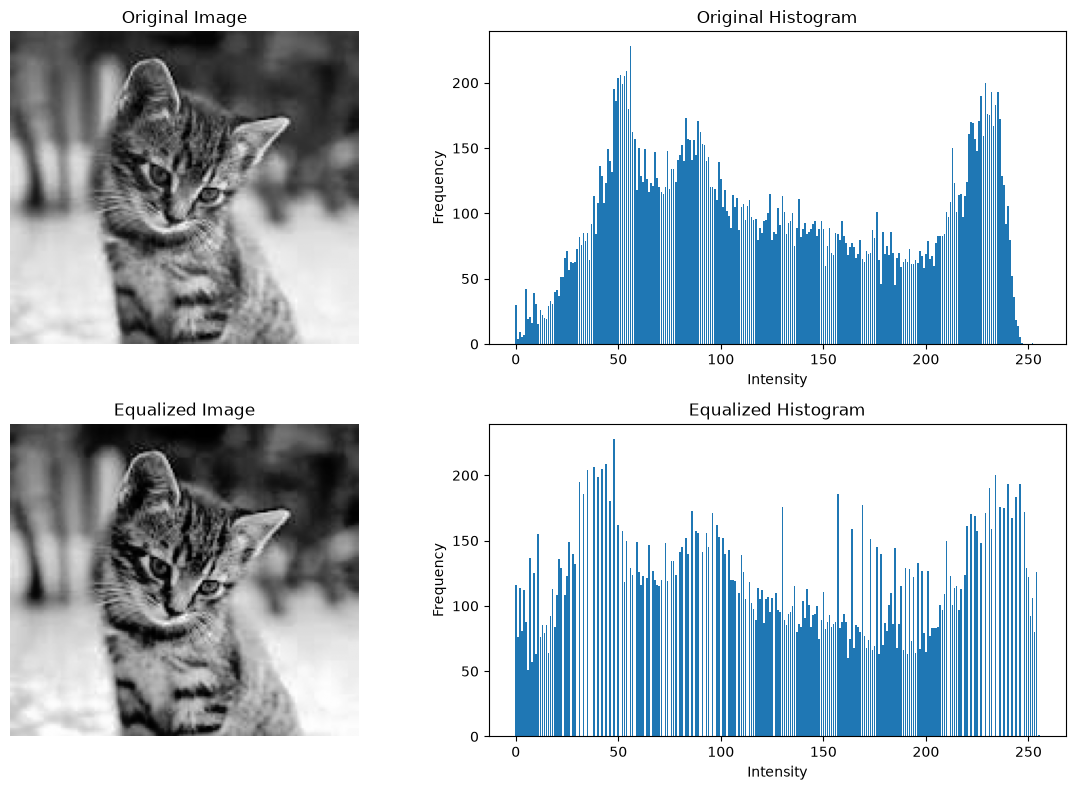

In [8]:
# =================================
# 5. Display Results
# =================================

plt.figure(figsize=(12, 8))

# Original Image
plt.subplot(2, 2, 1)
plt.imshow(image, cmap="gray")
plt.title("Original Image")
plt.axis("off")

# Original Histogram
plt.subplot(2, 2, 2)
plt.bar(range(256), histogram)
plt.title("Original Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

# Equalized Image
plt.subplot(2, 2, 3)
plt.imshow(equalized, cmap="gray")
plt.title("Equalized Image")
plt.axis("off")

# Equalized Histogram
plt.subplot(2, 2, 4)
plt.bar(range(256), equalized_histogram)
plt.title("Equalized Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()